In [1]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
import random
import numpy as np

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

# from model import SeqNN
from model_v2_compatible import SeqNN

In [3]:
FOLD = 2

# fold 0 - test
# fold 1 - valid
# folds 2-7 - train

In [4]:
TARGET_C = 0.5

In [5]:
df = pd.read_csv(f"/scratch1/smaruj/generate_genomic_fountains/fold{FOLD}_{TARGET_C}_CONE_selected_genomic_windows_centered_with_steps.tsv", sep="\t")

In [ ]:
# df = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_selected_genomic_windows_centered.tsv", sep="\t")

In [ ]:
len(df)

In [ ]:
# df["flat_length"] = df["flat_end_query"] - df["flat_start_query"]

In [ ]:
df

In [ ]:
# df = df.rename(columns={"centered_start_query": "centered_start", "centered_end_query": "centered_end", "chrom_query": "chrom"})

In [6]:
class OriginalDataset(Dataset):
    def __init__(self, coord_df, init_seq_path):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
    
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        X = X.squeeze(0)
        return X

In [7]:
class FountainGenerationDataset(Dataset):
    def __init__(self, coord_df, init_seq_path, slice_path, slice=[i for i in range(231, 281)], cropping=64, bin_size=2048):
        self.coords = coord_df
        self.init_seq_path = init_seq_path
        self.slice_path = slice_path
        self.slice = slice
        self.cropping = cropping
        self.bin_size = bin_size
        
    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        X = torch.load(f"{self.init_seq_path}{chrom}_{start}_{end}_X.pt", weights_only=True)
        slice = torch.load(f"{self.slice_path}{chrom}_{start}_{end}_slice.pt", weights_only=True)

        edit_start = (min(self.slice) + self.cropping) * self.bin_size
        edit_end = (max(self.slice) + 1 + self.cropping) * self.bin_size
        
        editedX = X.clone()
        editedX[:,:, edit_start:edit_end] = slice
        
        editedX = editedX.squeeze(0)
        
        return editedX

In [8]:
class TriuMatrixDataset(Dataset):
    def __init__(self, coord_df, map_path):
        """
        coord_df: DataFrame with ["chrom", "centered_start", "centered_end"]
        map_path: Directory containing upper-triangle map tensors (e.g. chr1_1000000_1051200_target.pt)
        """
        self.coords = coord_df
        self.map_path = map_path

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        row = self.coords.iloc[idx]
        chrom = row["chrom"]
        start = row["centered_start"]
        end = row["centered_end"]

        file_name = f"{chrom}_{start}_{end}_target.pt"
        file_path = os.path.join(self.map_path, file_name)

        # Load the flat upper-triangular vector
        triu_tensor = torch.load(file_path, map_location='cpu')

        # triu_tensor = triu_tensor.squeeze()

        return triu_tensor

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
model = SeqNN()
model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_finetuned_correctly.pt", map_location=device))
model.eval()

/tmp/SLURM_1127400/ipykernel_1713069/2744654124.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("/home1/smaruj/pytorch_akita/model_0_v2_

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 128, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (batch_norm): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size=2, stride=2, paddi

In [11]:
def set_diag(matrix, value, k):
    """Set diagonal `k` of a matrix to `value`."""
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu_batch(batch_vectors, matrix_len=512, num_diags=2):
    """Convert a batch of upper-triangular vectors into symmetric matrices with np.nan on diagonals."""
    if isinstance(batch_vectors, torch.Tensor):
        batch_vectors = batch_vectors.detach().cpu().numpy()

    batch_size = len(batch_vectors)
    matrices = np.zeros((batch_size, matrix_len, matrix_len), dtype=np.float32)

    triu_indices = np.triu_indices(matrix_len, num_diags)

    for i in range(batch_size):
        matrices[i][triu_indices] = batch_vectors[i][0,:]
        # Mirror to lower triangle
        matrices[i] = matrices[i] + matrices[i].T

        # Set diagonals to np.nan
        for k in range(-num_diags + 1, num_diags):
            set_diag(matrices[i], np.nan, k)

    return matrices  # shape: [B, 512, 512]

In [12]:
def create_upper_right_antidiagonal_band_mask(shape=(512, 512), max_dist=120):
    H, W = shape
    i, j = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')

    # Antidiagonal line points:
    p1 = np.array([0, W-1])       # top-right corner
    p2 = np.array([H-1, 0])       # bottom-left corner

    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unit = line_vec / line_len

    pix_vecs = np.stack([i - p1[0], j - p1[1]], axis=-1)

    t = np.sum(pix_vecs * line_unit, axis=-1)

    # Limit t to first half of the line (top-right corner to center)
    center_t = line_len / 2
    valid_t = (t >= 0) & (t <= center_t)

    t_clipped = np.clip(t, 0, center_t)

    closest = p1 + (t_clipped[..., None] * line_unit)

    dist_to_line = np.linalg.norm(np.stack([i, j], axis=-1) - closest, axis=-1)

    # Linearly decreasing max distance from max_dist at t=0 to 0 at t=center_t
    max_allowed_dist = max_dist * (1 - (t_clipped / center_t))

    # Mask only where t in [0, center_t] and dist_to_line within allowed band
    mask = (dist_to_line <= max_allowed_dist) & valid_t

    return mask

In [13]:
orig_dataset = OriginalDataset(df, f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/")
orig_loader = DataLoader(orig_dataset, batch_size=4, shuffle=False)

In [14]:
edited_dataset = FountainGenerationDataset(df, 
                                f"/scratch1/smaruj/genomic_insertion_loci/ohe_X/fold{FOLD}/", 
                                f"/scratch1/smaruj/generate_genomic_fountains/results_{TARGET_C}/fold{FOLD}/")

edited_loader = DataLoader(edited_dataset, batch_size=4, shuffle=False)

In [15]:
target_dataset = TriuMatrixDataset(df, f"/scratch1/smaruj/generate_genomic_fountains/targets_{TARGET_C}/fold{FOLD}/")

target_loader = DataLoader(target_dataset, batch_size=4, shuffle=False)

In [ ]:
# df

In [16]:
slice = [i for i in range(231, 281)]
cropping = 64
bin_size = 2048

edit_start = (min(slice) + cropping) * bin_size
edit_end = (max(slice) + 1 + cropping) * bin_size

In [ ]:
edit_start, edit_end

In [17]:
def average_in_mask_batch(maps, mask):
    """
    maps: numpy array of shape (B, H, W)
    mask: boolean numpy array of shape (H, W) defining region of interest
    
    Returns:
        averages: numpy array of shape (B,) with average values inside mask per map,
                  ignoring NaNs.
    """
    # Expand mask for broadcasting over batch dimension
    mask_exp = mask[None, :, :]  # shape (1, H, W)

    # Masked values, keep NaNs for now
    masked_values = np.where(mask_exp, maps, np.nan)

    # Compute nanmean over masked region for each map in batch
    averages = np.nanmean(masked_values, axis=(1,2))

    return averages

In [18]:
ag_mask = create_upper_right_antidiagonal_band_mask()

In [19]:
preds_all_orig = []
preds_all_edited = []
targets_all = []
scd_values = []
edit_counts = []
seq_GC_content = []
slice_GC_content = []
edited_GC_content = []
flat_GC_content = []

ed_anti_diag = []
og_anti_diag = []

# flat_lengths = df["flat_length"].values
counter = 0

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch, target_batch in zip(orig_loader, edited_loader, target_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        target_batch = target_batch.to(device)
        target_batch = target_batch.squeeze(1)
        
        # B, _, L = orig_batch.shape
        # batch_flat_lengths = flat_lengths[counter:counter + B]
        # center = L // 2
        
        # Compute GC content
        gc_content_all = orig_batch[:, 1:3, :].sum(dim=1) / orig_batch.sum(dim=1)  # [B, L]
        gc_content_slice = orig_batch[:, 1:3, edit_start:edit_end].sum(dim=1) / orig_batch[:, :, edit_start:edit_end].sum(dim=1)  # [B, edited_L]
        gc_content_slice_edit = edited_batch[:, 1:3, edit_start:edit_end].sum(dim=1) / edited_batch[:, :, edit_start:edit_end].sum(dim=1)  # [B, edited_L]
        
        # Mean GC content per sequence
        mean_gc_all = gc_content_all.mean(dim=1).cpu().numpy()  # [B]
        mean_gc_slice = gc_content_slice.mean(dim=1).cpu().numpy()  # [B]
        mean_gc_edit = gc_content_slice_edit.mean(dim=1).cpu().numpy()  # [B]
        
        seq_GC_content.extend(mean_gc_all)
        slice_GC_content.extend(mean_gc_slice)
        edited_GC_content.extend(mean_gc_edit)
        
        # # Flat region GC content
        # for i in range(B):
        #     half_len = batch_flat_lengths[i] // 2
        #     start = int(max(center - half_len, 0))
        #     end = int(min(center + half_len, L))
            
        #     orig_slice = orig_batch[i, :, start:end]
        #     orig_gc = orig_slice[1:3].sum() / orig_slice.sum()

        #     flat_GC_content.append(orig_gc.item())
            
        # counter += B
        
        diffs = torch.abs(orig_batch[:, :, edit_start:edit_end] - edited_batch[:, :, edit_start:edit_end])  # shape [B, 4, region_len]
        num_flips = diffs.sum(dim=(1, 2))  # total bit flips per sequence
        num_edits = (num_flips / 2).cpu().numpy()  # divide by 2 to get base edits
        
        edit_counts.extend(num_edits)
        
        preds_orig = model(orig_batch).cpu()
        preds_edited = model(edited_batch).cpu()

        preds_all_orig.extend(preds_orig)
        preds_all_edited.extend(preds_edited)
        targets_all.extend(target_batch)
        
        scd_batch = torch.sqrt(((preds_edited - preds_orig) ** 2).sum(dim=(1, 2)))  # [B]
        scd_values.extend(scd_batch.numpy())
        
        orig_maps = from_upper_triu_batch(preds_orig)
        edited_maps = from_upper_triu_batch(preds_edited)
        
        edited_ad_metric = average_in_mask_batch(edited_maps, ag_mask)
        og_ad_metric = average_in_mask_batch(orig_maps, ag_mask)
        # calculate_antidiagonal_metric_batch(target_batch)
        
        ed_anti_diag.extend(edited_ad_metric)
        og_anti_diag.extend(og_ad_metric)

/tmp/SLURM_1127400/ipykernel_1713069/1974969080.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  triu_tensor = torch.load(file_path, map_location='cpu')


In [20]:
bin_size = 2048
region_len = edit_end - edit_start
n_bins = region_len // bin_size

In [21]:
gc_content_bins_orig = []  # list of lists: outer list over sequences, inner list over bins
gc_content_bins_edit = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch, target_batch in zip(orig_loader, edited_loader, target_loader):
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        for i in range(orig_batch.shape[0]):  # batch size
            per_seq_gc_orig = []
            per_seq_gc_edit = []

            for b in range(n_bins):
                bin_start = edit_start + b * bin_size
                bin_end = bin_start + bin_size

                # Original sequence GC content in this bin
                orig_bin = orig_batch[i, :, bin_start:bin_end]
                gc_count_orig = orig_bin[1:3].sum()
                total_count_orig = orig_bin.sum()
                gc_ratio_orig = (gc_count_orig / total_count_orig).item() if total_count_orig > 0 else float('nan')
                per_seq_gc_orig.append(gc_ratio_orig)

                # Edited sequence GC content in this bin
                edit_bin = edited_batch[i, :, bin_start:bin_end]
                gc_count_edit = edit_bin[1:3].sum()
                total_count_edit = edit_bin.sum()
                gc_ratio_edit = (gc_count_edit / total_count_edit).item() if total_count_edit > 0 else float('nan')
                per_seq_gc_edit.append(gc_ratio_edit)

            gc_content_bins_orig.append(per_seq_gc_orig)
            gc_content_bins_edit.append(per_seq_gc_edit)

/tmp/SLURM_1127400/ipykernel_1713069/1974969080.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  triu_tensor = torch.load(file_path, map_location='cpu')


In [22]:
gc_orig = np.array(gc_content_bins_orig)
gc_edit = np.array(gc_content_bins_edit)

In [23]:
# Compute average GC content across sequences per bin
avg_gc_orig = np.nanmean(gc_orig, axis=0)  # shape: [n_bins]
avg_gc_edit = np.nanmean(gc_edit, axis=0)  # shape: [n_bins]

In [24]:
import matplotlib.pyplot as plt

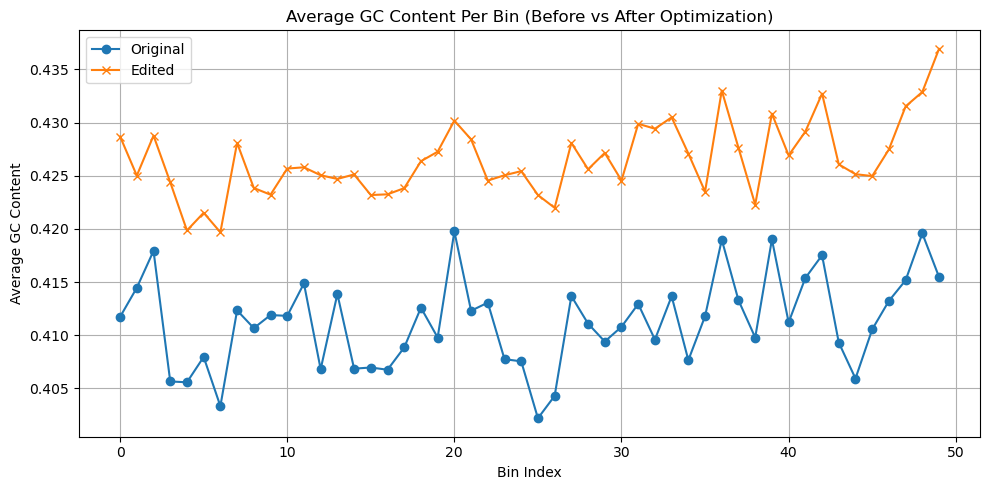

In [25]:
# Plot
plt.figure(figsize=(10, 5))
bins = np.arange(len(avg_gc_orig))

plt.plot(bins, avg_gc_orig, label="Original", marker='o')
plt.plot(bins, avg_gc_edit, label="Edited", marker='x')
plt.xlabel("Bin Index")
plt.ylabel("Average GC Content")
plt.title("Average GC Content Per Bin (Before vs After Optimization)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
CTCF_PWM = "/home1/smaruj/IterativeMutagenesis/MA0139.1.meme"

In [27]:
def read_meme_pwm_as_numpy(filename):
    pwm_list = []  # List to store PWM rows
    
    with open(filename, 'r') as file:
        in_matrix_section = False
        
        for line in file:
            line = line.strip()
            
            # Check if we are reading the PWM matrix
            if line.startswith("letter-probability matrix"):
                in_matrix_section = True  # Start reading matrix data
                continue  # Skip this header line
            
            # If we are in the matrix section, process the rows
            if in_matrix_section and line:
                pwm_row = [float(value) for value in line.split()]  # Parse values
                pwm_list.append(pwm_row)  # Append to the PWM list
            
            # If we encounter a new MOTIF or the end of file, stop matrix reading
            if line.startswith("MOTIF") and in_matrix_section:
                break
    
    # Convert the list to a numpy array
    pwm_array = np.array(pwm_list)
    
    return pwm_array

In [28]:
pwm_CTCF = read_meme_pwm_as_numpy(CTCF_PWM)
pwm_CTCF_tensor = torch.from_numpy(pwm_CTCF.T).float()
motifs_dict = {"CTCF": pwm_CTCF_tensor}

In [29]:
from tangermeme.tools import fimo

In [ ]:
# batch_size = 4

# orig_num_CTCFs = []

# num_CTCFs = []
# sum_FIMO = []
# max_FIMO = []

# model.eval()
# with torch.no_grad():
#     for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
#         orig_batch = orig_batch.to(device)
#         edited_batch = edited_batch.to(device)
        
#         orig_slice = orig_batch[:, :, edit_start:edit_end]
#         edited_slice = edited_batch[:, :, edit_start:edit_end]
        
#         orig_hits = fimo.fimo(
#             motifs=motifs_dict,
#             sequences=orig_slice,
#             threshold=1e-4,
#             reverse_complement=True
#         )[0]
        
#         for seq_idx in range(batch_size):
#             seq_hits = orig_hits[orig_hits["sequence_name"] == seq_idx]
            
#             if not seq_hits.empty:
#                 orig_num_CTCFs.append(len(seq_hits))
#             else:
#                 orig_num_CTCFs.append(0)
        
#         hits = fimo.fimo(
#             motifs=motifs_dict,
#             sequences=edited_slice,
#             threshold=1e-4,
#             reverse_complement=True
#         )[0]
        
#         for seq_idx in range(batch_size):
#             seq_hits = hits[hits["sequence_name"] == seq_idx]
            
#             if not seq_hits.empty:
#                 num_CTCFs.append(len(seq_hits))
#                 sum_FIMO.append(seq_hits["score"].sum())
#                 max_FIMO.append(seq_hits["score"].max())
#             else:
#                 num_CTCFs.append(0)
#                 sum_FIMO.append(0.0)
#                 max_FIMO.append(0.0)

In [30]:
from collections import defaultdict

In [31]:
batch_size = 4

orig_num_CTCFs = []
orig_sum_FIMO = []
orig_max_FIMO = []
 
num_CTCFs = []
sum_FIMO = []
max_FIMO = []
strand_strings = []
positions = []

extra_flank = 60
bin_size = 2048
n_bins = 50

per_bin_CTCFs = []

model.eval()
with torch.no_grad():
    for orig_batch, edited_batch in zip(orig_loader, edited_loader):
        
        orig_batch = orig_batch.to(device)
        edited_batch = edited_batch.to(device)
        
        orig_slice = orig_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        edited_slice = edited_batch[:, :, edit_start-extra_flank:edit_end+extra_flank]
        
        orig_hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=orig_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = orig_hits[orig_hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                seq_hits = seq_hits.sort_values(by="start")
                
                orig_num_CTCFs.append(len(seq_hits))
                orig_sum_FIMO.append(seq_hits["score"].sum())
                orig_max_FIMO.append(seq_hits["score"].max())
            else:
                orig_num_CTCFs.append(0)
                orig_sum_FIMO.append(0)
                orig_max_FIMO.append(0)
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]

        per_seq_bin_CTCFs = []  # one per sequence 
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            bin_orientations = defaultdict(str)  # key: bin_idx, value: concatenated strand symbols
            
            if not seq_hits.empty:
                seq_hits = seq_hits.sort_values(by="start")
                
                seq_positions = []
                
                num_CTCFs.append(len(seq_hits))
                sum_FIMO.append(seq_hits["score"].sum())
                max_FIMO.append(seq_hits["score"].max())
                
                for _, row in seq_hits.iterrows():
                    hit_start = row['start'] + extra_flank
                    hit_end = row['end'] + extra_flank
                    hit_strand = row['strand']
                    
                    bin_idx = hit_start // bin_size
                    if 0 <= bin_idx < n_bins + 1:
                        bin_orientations[bin_idx] += hit_strand
                    
                    seq_positions.append((hit_start, hit_end))
                    
                positions.append(seq_positions)
                strand_concat = ''.join(seq_hits["strand"].tolist())
                strand_strings.append(strand_concat)
                
                per_bin_CTCFs.append(sorted(bin_orientations.items()))
                
            else:
                num_CTCFs.append(0)
                sum_FIMO.append(0.0)
                max_FIMO.append(0.0)
                positions.append(tuple())
                strand_strings.append("no")
                per_seq_bin_CTCFs.append([])


In [32]:
avg_num_CTCFs = np.mean(num_CTCFs)

In [33]:
avg_num_CTCFs

11.4

In [34]:
from collections import Counter

In [35]:
# Count number of CTCFs per bin across all sequences
ctcf_count_per_bin = Counter()
for seq in per_bin_CTCFs:
    for bin_idx, strand in seq:
        ctcf_count_per_bin[bin_idx] += len(strand)

bins = sorted(ctcf_count_per_bin)
counts = [ctcf_count_per_bin[b] for b in bins]

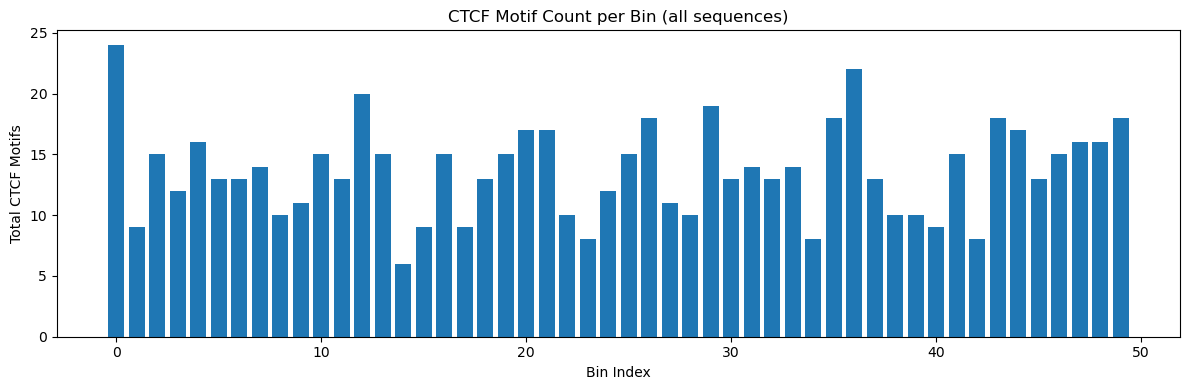

In [36]:
plt.figure(figsize=(12, 4))
plt.bar(bins, counts)
plt.xlabel("Bin Index")
plt.ylabel("Total CTCF Motifs")
plt.title("CTCF Motif Count per Bin (all sequences)")
plt.tight_layout()
plt.show()

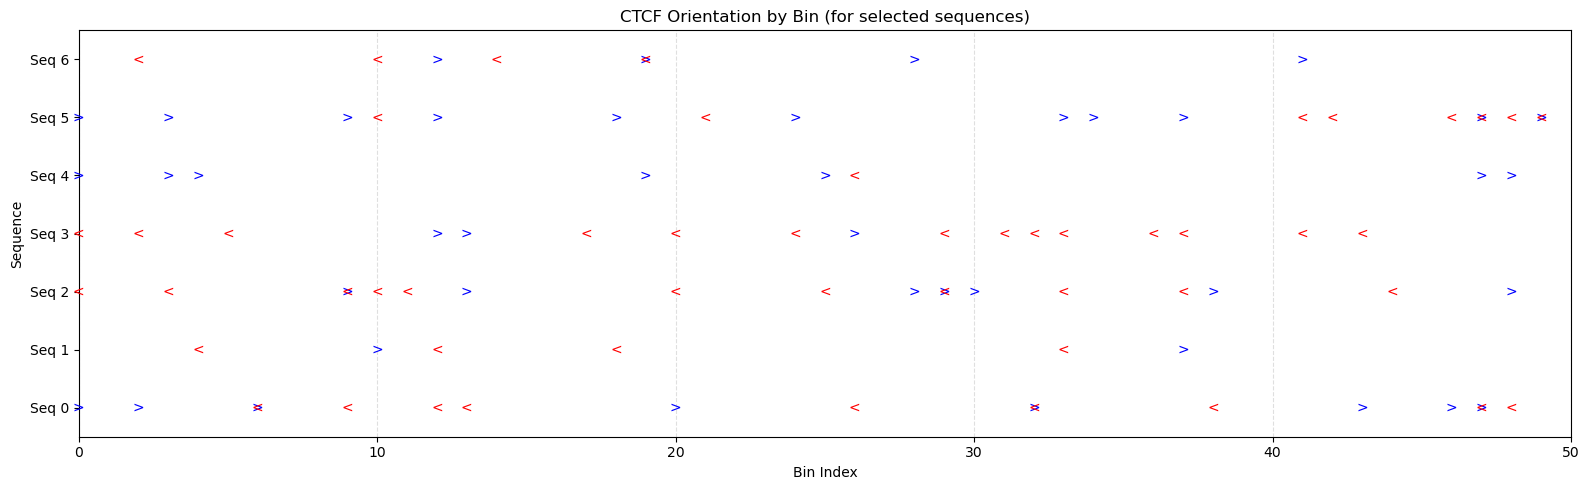

In [37]:
# Select indices of 7 sequences to show
selected_indices = [0, 1, 2, 3, 4, 5, 6]

plt.figure(figsize=(16, 5))

for row_idx, seq_idx in enumerate(selected_indices):
    # Collect bin-orientation data for that sequence
    seq_bins = per_bin_CTCFs[seq_idx]
    
    for bin_idx, orientation in seq_bins:
        if '+' in orientation or '>' in orientation:
            plt.text(bin_idx, row_idx, '>', color='blue', ha='center', va='center', fontsize=10)
        if '-' in orientation or '<' in orientation:
            plt.text(bin_idx, row_idx, '<', color='red', ha='center', va='center', fontsize=10)

# Axis formatting
plt.yticks(range(len(selected_indices)), [f"Seq {i}" for i in selected_indices])
plt.xlabel("Bin Index")
plt.ylabel("Sequence")
plt.title("CTCF Orientation by Bin (for selected sequences)")
plt.xlim(0, 50)
plt.ylim(-0.5, len(selected_indices) - 0.5)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [38]:
orig_preds_all = torch.cat(preds_all_orig, dim=0)
edited_preds_all = torch.cat(preds_all_edited, dim=0)
targets_all = torch.cat(targets_all, dim=0)

In [ ]:
# flat_GC_content

In [39]:
import matplotlib.pyplot as plt

In [40]:
df["SCD"] = scd_values

df["ed_anti_diag30"] = ed_anti_diag
df["og_anti_diag30"] = og_anti_diag

df["num_edits"] = edit_counts
df["GC_seq"] = seq_GC_content
df["GC_slice"] = slice_GC_content
df["GC_slice_edited"] = edited_GC_content
# df["flat_GC_content"] = flat_GC_content

In [41]:
df["per_bin_GC_og"] = gc_content_bins_orig
df["per_bin_GC_ed"] = gc_content_bins_edit

In [42]:
df["init_CTCFs_num"] = orig_num_CTCFs[:len(df)]
df["init_sum_FIMO"] = orig_sum_FIMO[:len(df)]
df["init_max_FIMO"] = orig_max_FIMO[:len(df)]

df["CTCFs_num"] = num_CTCFs[:len(df)]
df["FIMO_sum"] = sum_FIMO[:len(df)]
df["FIMO_max"] = max_FIMO[:len(df)]
df["orientation"] = strand_strings[:len(df)]
df["positions"] = positions[:len(df)]

In [43]:
df["bin_CTCFs"] = per_bin_CTCFs[:len(df)]

In [ ]:
df.columns

In [ ]:
df.head()

In [ ]:
# df["ed_anti_diag30"]

In [ ]:
# df

In [44]:
df.to_csv(f"/scratch1/smaruj/generate_genomic_fountains/CONE_fold{FOLD}_{TARGET_C}_results.tsv", sep="\t", index=False)

# df.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/reproducibility_fold0_-0.5/seed{SEED}_results.tsv", sep="\t", index=False)

In [ ]:
batch_size = 4
flank_size = 15
ctcf_ohe_seqs = []  # list to collect OHE motif+flank arrays
ctcf_ohe_scores = [] # FIMO

model.eval()
with torch.no_grad():
    for edited_batch in edited_loader:
        
        edited_batch = edited_batch.to(device)
        edited_slice = edited_batch[:, :, edit_start:edit_end]  # shape: [B, 4, L]
        
        hits = fimo.fimo(
            motifs=motifs_dict,
            sequences=edited_slice,
            threshold=1e-4,
            reverse_complement=True
        )[0]
        
        for seq_idx in range(batch_size):
            seq_hits = hits[hits["sequence_name"] == seq_idx]
            
            if not seq_hits.empty:
                for _, row in seq_hits.iterrows():
                    start = int(row["start"]) - flank_size
                    end = int(row["end"]) + flank_size
                    strand = row["strand"]
                    
                    # Make sure bounds are within slice
                    if start < 0 or end > edited_slice.shape[-1]:
                        continue
                    
                    subseq = edited_slice[seq_idx, :, start:end]  # shape: [4, motif_len+30]
                    
                    if strand == '-':
                        # Reverse sequence
                        subseq = torch.flip(subseq, dims=[-1])  # reverse along the sequence axis

                        # Complement the one-hot rows: A<->T, C<->G
                        complement_map = torch.tensor([3, 2, 1, 0], device=subseq.device)  # old row i becomes new row complement_map[i]
                        subseq = subseq[complement_map, :]
    
                    ctcf_ohe_seqs.append(subseq.cpu().numpy())  # store as numpy array
                    ctcf_ohe_scores.append(row["score"])

In [ ]:
top_indices = np.argsort(ctcf_ohe_scores)[-20:][::-1]  # descending order

In [ ]:
# Extract the top sequences
top_ctcf_ohe = [ctcf_ohe_seqs[i] for i in top_indices]
top_scores = [ctcf_ohe_scores[i] for i in top_indices]

In [ ]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list

In [ ]:
# Assume top_ctcf_ohe is a list of 20 np.arrays with shape (4, 49)
# Stack them into a single array of shape (20, 4, 49)
seq_array = np.stack(top_ctcf_ohe)  # shape: [20, 4, 49]

# Convert from one-hot to integer-encoded sequences (A=0, C=1, G=2, T=3)
int_encoded = np.argmax(seq_array, axis=1)  # shape: [20, 49]

# Compute pairwise Hamming distances
distance_matrix = squareform(pdist(int_encoded, metric='hamming'))

# Use hierarchical clustering to order sequences
order = leaves_list(linkage(distance_matrix))

# Reorder the sequences
ordered_seqs = int_encoded[order]  # shape: [20, 49]

In [ ]:
# Map base integers to RGB colors
color_map = {
    0: [0.0, 1.0, 0.0],   # A - green
    1: [0.0, 0.0, 1.0],   # C - blue
    2: [1.0, 1.0, 0.0],   # G - yellow
    3: [1.0, 0.0, 0.0],   # T - red
}
rgb_array = np.array([[color_map[base] for base in row] for row in ordered_seqs])  # shape: [20, 49, 3]

In [ ]:
# Plotting
plt.figure(figsize=(12, 6))
plt.imshow(rgb_array, aspect='auto')
plt.title('Ordered CTCF Motifs (by Hamming Distance)')
plt.xlabel('Position')
plt.ylabel('Sequence Index')
plt.xticks(ticks=np.linspace(0, 48, 7), labels=[f'{int(x)}' for x in np.linspace(1, 49, 7)])
plt.yticks(ticks=np.arange(20), labels=[str(i + 1) for i in range(20)])
plt.tight_layout()
plt.show()

### SCD

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["SCD"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("SCD")
plt.ylabel("Count")
plt.title("Distribution of SCD values")
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(scd_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(scd_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs SCD")
    axes[i].set_xlabel("SCD Value")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### URQ mean

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("URQ mean")
plt.ylabel("Count")
plt.title("Distribution of URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(target_urq_mean_values, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Target URQ mean")
plt.ylabel("Count")
plt.title("Distribution of Target URQ mean values")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import pearsonr

In [ ]:
# Compute Pearson R
r_val, p_val = pearsonr(urq_mean_values, target_urq_mean_values)

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, target_urq_mean_values, alpha=0.6, edgecolors='k')

plt.xlabel("Edited URQ Mean")
plt.ylabel("Target URQ Mean")
plt.title("URQ Mean: Edited vs. Target")

# Annotate with Pearson R
plt.text(0.05, 0.95, f"Pearson R = {r_val:.3f}", transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Make sure scd_values is a list or Series of same length as pivoted
assert len(urq_mean_values) == len(df), "Length mismatch!"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

state_labels = ["active", "neutral", "repressive"]

for i, label in enumerate(state_labels):
    axes[i].scatter(urq_mean_values, df[f"{label}_fraction"], alpha=0.7)
    axes[i].set_title(f"{label.capitalize()} Fraction vs URQ mean")
    axes[i].set_xlabel("URQ mean")
    if i == 0:
        axes[i].set_ylabel("Fraction")

plt.tight_layout()
plt.show()

### edit count

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(edit_counts, bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Number of edits / 2048bp-long bin")
plt.ylabel("Count")
plt.title("Distribution of edits number")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["last_accepted_step_query"], bins=30, color='steelblue', edgecolor='black')
plt.xlabel("Last step with accepted edits")
plt.ylabel("Count")
plt.title("Distribution of last step with accepted edits")
plt.tight_layout()
plt.show()

### GC content

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(edit_counts, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("number of edits")
plt.ylabel("Seq GC content")
plt.title("number of edits vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(df["last_accepted_step_query"], seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("last step with accepted edit")
plt.ylabel("Seq GC content")
plt.title("last step with accepted edit vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(urq_mean_values, seq_GC_content, alpha=0.6, edgecolors='k')

plt.xlabel("URQ mean")
plt.ylabel("Seq GC content")
plt.title("URQ mean vs. Seq GC content")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# df.to_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold{FOLD}_{TARGET_C}_all_data.tsv", sep="\t", index=False)

In [ ]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [ ]:
df[df["SCD"] < 50]

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i, :], matrix_len=512, num_diags=2)
    mask = create_upper_right_antidiagonal_band_mask(max_dist=120)

    plt.figure(figsize=(6, 6))
    plt.imshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar(label="value")

    plt.contour(mask.astype(int), levels=[0.5], colors='lime', linewidths=2)
    plt.scatter([256], [256], color='black', s=40, label='Matrix Center')

    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:] - orig_preds_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(edited_preds_all[i,:], matrix_len=512, num_diags=2)
    mask = create_upper_right_antidiagonal_band_mask(max_dist=120)

    plt.figure(figsize=(5, 5))
    plt.imshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar(label="value")

    plt.contour(mask.astype(int), levels=[0.5], colors='lime', linewidths=2)
    plt.scatter([256], [256], color='black', s=40, label='Matrix Center')

    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
for i in range(4):
    print(i)
    matrix = from_upper_triu(targets_all[i,:], matrix_len=512, num_diags=2)
    
    plt.figure(figsize=(5, 5))
    plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    plt.colorbar()
    plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Reshape to long format
plot_df = pd.melt(df, 
                  value_vars=['og_anti_diag30', 'ed_anti_diag30'],
                  var_name='Version', 
                  value_name='Score')

# Rename for prettier labels (optional)
plot_df['Version'] = plot_df['Version'].replace({
    'og_anti_diag30': 'Original',
    'ed_anti_diag30': 'Edited'
})

# Plot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Version', y='Score', data=plot_df)
plt.ylabel('Average Value in Antidiagonal Mask (cone score)')
plt.title('Original vs Edited Region Scores')
plt.tight_layout()
plt.show()